In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS=3
EPOCHS=50

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2153 files belonging to 3 classes.


In [4]:
class_names=dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
len(dataset)

68

In [6]:
# for image_batch, label_batch in dataset.take(1):
#     print(image_batch.shape)
#     print(label_batch.numpy())

for image_batch, label_batch in dataset.take(1):
    print(image_batch[0])

tf.Tensor(
[[[128. 129. 147.]
  [123. 124. 142.]
  [134. 135. 153.]
  ...
  [118. 120. 133.]
  [131. 133. 146.]
  [133. 135. 148.]]

 [[152. 153. 171.]
  [129. 130. 148.]
  [126. 127. 145.]
  ...
  [129. 131. 144.]
  [138. 140. 153.]
  [139. 141. 154.]]

 [[127. 128. 146.]
  [113. 114. 132.]
  [128. 129. 147.]
  ...
  [119. 121. 134.]
  [124. 126. 139.]
  [126. 128. 141.]]

 ...

 [[168. 171. 190.]
  [181. 184. 203.]
  [176. 179. 198.]
  ...
  [199. 201. 213.]
  [180. 182. 194.]
  [188. 190. 202.]]

 [[170. 173. 192.]
  [178. 181. 200.]
  [180. 183. 202.]
  ...
  [197. 199. 211.]
  [181. 183. 195.]
  [196. 198. 210.]]

 [[172. 175. 194.]
  [159. 162. 181.]
  [169. 172. 191.]
  ...
  [177. 179. 191.]
  [160. 162. 174.]
  [176. 178. 190.]]], shape=(256, 256, 3), dtype=float32)


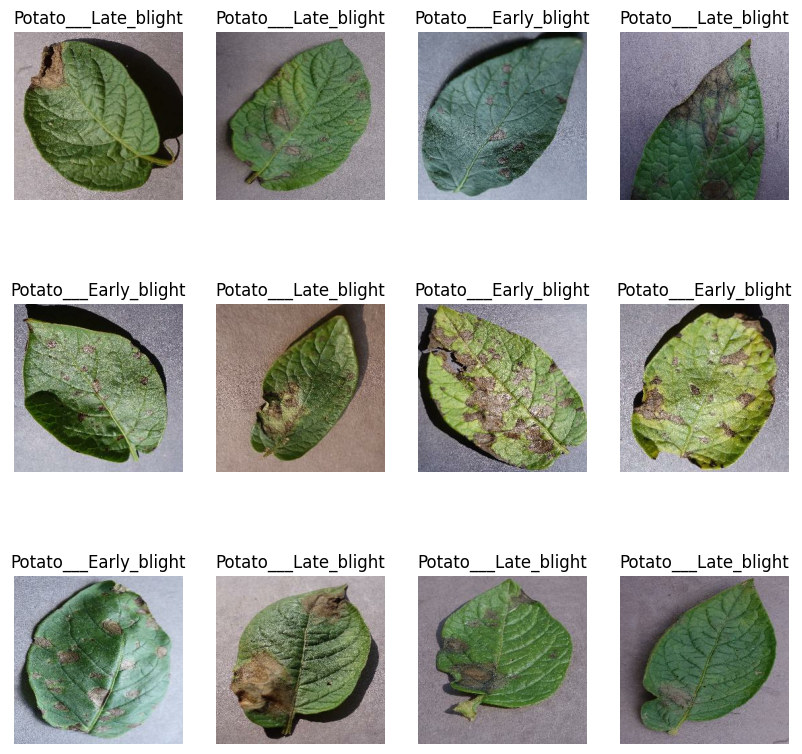

In [7]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [8]:
# 80% ==> training
# 20% ==> 10% validation, 10% ==> test

In [9]:
train_size=0.8
len(dataset)*train_size

54.400000000000006

In [10]:
train_ds=dataset.take(54)
test_ds=dataset.skip(54)

In [12]:
val_ds=test_ds.take(6)
test_ds=test_ds.skip(6)

In [15]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size= len(ds)

    if shuffle:
        ds=ds.shuffle(shuffle_size, seed=12)
    
    train_size= int(train_split*ds_size)
    val_size=int(val_split*ds_size)
    
    train_ds=ds.take(train_size)

    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [16]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [18]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [19]:
tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])

AttributeError: module 'keras._tf_keras.keras.layers' has no attribute 'experimental'